In [1]:
# 1 LOAD MODULES 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import tensorflow as tf
from collections import Counter
import numpy as np
from collections import Counter
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D ,Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping


print('modules loaded')




2025-06-11 09:49:38.478908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749628178.628011    3627 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749628178.665461    3627 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-11 09:49:39.026632: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


modules loaded


In [2]:
# 1 PREPROCESS THE DATA AND DATA  AUGEMENTATION

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_CPP_MIN_VLOG_LEVEL'] = '3'


# Data augmentation setup
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=(0.7, 1.3),
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "../FOMO/ESP_32/train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "../FOMO/ESP_32/train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)





Found 980 images belonging to 4 classes.
Found 244 images belonging to 4 classes.


In [3]:
print(train_data.class_indices)
labels = train_data.classes  
class_counts = Counter(labels)
index_to_class = {v: k for k, v in train_data.class_indices.items()}

for class_index, count in class_counts.items():
    print(f"{index_to_class[class_index]}: {count} images")


{'cocii': 0, 'healthy': 1, 'ncd': 2, 'others': 3}
cocii: 464 images
healthy: 88 images
ncd: 210 images
others: 218 images


In [4]:
# MODEL FOR THE CLOUD
# 3 LOADING A PRETRAINED MODEL
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  

#OUR OWN TOP LAYER
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()



2025-06-11 09:52:53.225616: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# MODEL FOR THE EDGE DEVICE ESP32 CAM

num_classes = 4
esp32_model = tf.keras.Sequential([
    
   tf.keras.layers.Input(shape=(96, 96, 3))  ,

    tf.keras.layers.Conv2D(8, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

esp32_model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

esp32_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732 (6.77 KB)

 Trainable params: 1,732 (6.77 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# TRAINING THE MODELS

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, min_delta=0.001,)


history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,  
    callbacks=[early_stopping]
)

# esp32_history = esp32_model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=30,  
#     callbacks=[early_stopping])


/home/takudzwa/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 1/31 ━━━━━━━━━━━━━━━━━━━━ 2:47 6s/step - accuracy: 0.0500 - loss: 4.5055

2025-06-11 09:53:10.639556: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 18439680 exceeds 10% of free system memory.


 2/31 ━━━━━━━━━━━━━━━━━━━━ 22s 762ms/step - accuracy: 0.1788 - loss: 4.3601

2025-06-11 09:53:11.313944: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.
2025-06-11 09:53:11.347840: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29503488 exceeds 10% of free system memory.


 3/31 ━━━━━━━━━━━━━━━━━━━━ 23s 822ms/step - accuracy: 0.2542 - loss: 4.2728

2025-06-11 09:53:12.220118: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.
2025-06-11 09:53:12.244330: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29503488 exceeds 10% of free system memory.


31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5373 - loss: 3.6108 - val_accuracy: 0.6967 - val_loss: 2.7380
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7777 - loss: 2.4577 - val_accuracy: 0.7336 - val_loss: 2.2331
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8351 - loss: 2.0088 - val_accuracy: 0.7213 - val_loss: 1.9476
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.8246 - loss: 1.7724 - val_accuracy: 0.7500 - val_loss: 1.6995
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8503 - loss: 1.5187 - val_accuracy: 0.7623 - val_loss: 1.5879
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8638 - loss: 1.3593 - val_accuracy: 0.7910 - val_loss: 1.4839
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8929 - loss: 1.2365 - val_accuracy: 0.7746 - val_loss: 1.3847
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9166 - loss: 1.1086 - val_accuracy: 0.7254 - val_loss: 1.3768
Epo

In [7]:
#VALIDATION FO THE MODEL
# Evaluate FOMO model on validation data
val_images, val_labels = next(val_data) 
evaluation = model.evaluate(val_images, val_labels)
print(f"Cloud Model Loss: {evaluation[0]}")
print(f" Cloud Model Accuracy: {evaluation[1]}")

# evaluation =esp32_model.evaluate(val_images, val_labels)
# print(f"ESP32 Model Loss: {evaluation[0]}")
# print(f"ESP32 Model Accuracy: {evaluation[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8750 - loss: 0.7751
Cloud Model Loss: 0.7751214504241943
 Cloud Model Accuracy: 0.875


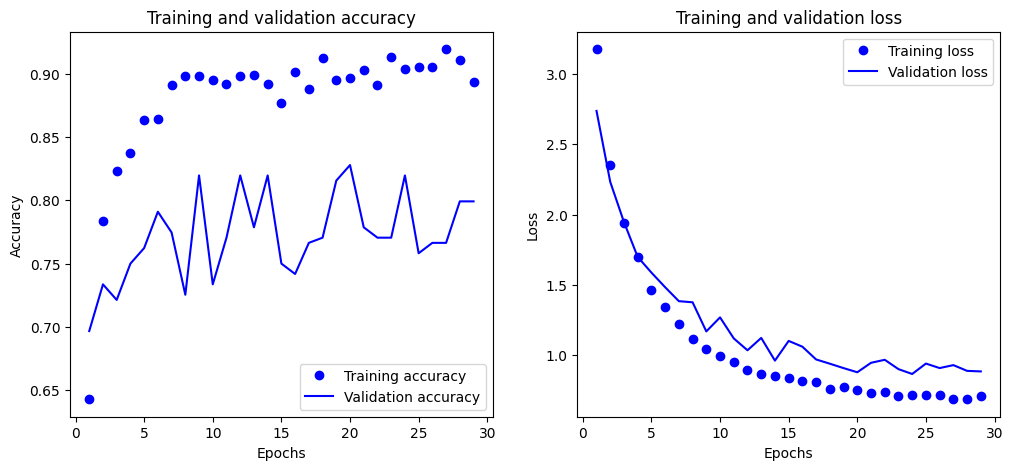

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss =history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

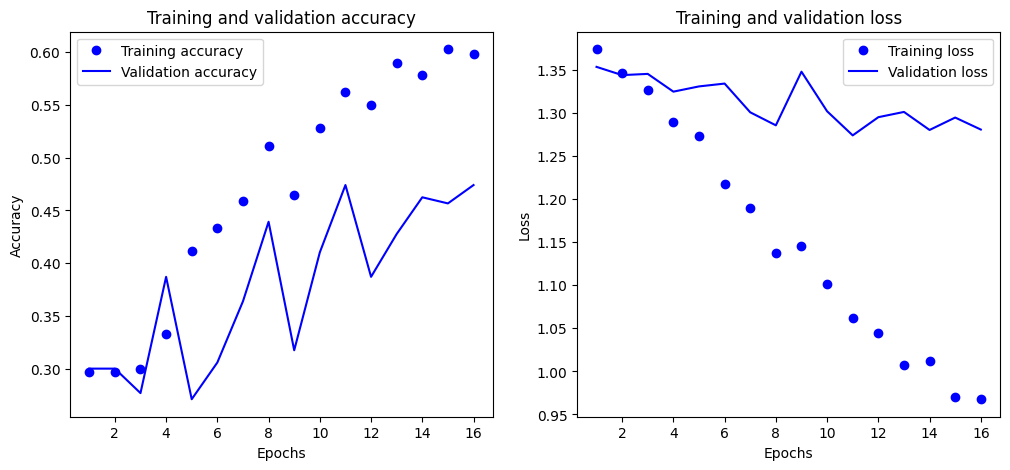

In [22]:
import matplotlib.pyplot as plt



acc = esp32_history.history['accuracy']
val_acc = esp32_history.history['val_accuracy']
loss = esp32_history.history['loss']
val_loss =esp32_history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# edge_model =esp32_model.save("broiler_model_edge.keras")
cloud_model =model.save("broiler_model_cloud.keras")

In [10]:
django_converter = tf.lite.TFLiteConverter.from_keras_model(model)
django_tflite_model = django_converter.convert()
django_path = '/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite'
with open(django_path, 'wb') as f:
    f.write(django_tflite_model)
print(f"Django model saved to: {django_path}")
print(f"Django model size: {len(django_tflite_model)/1024:.2f} KB")

#EDGE CONVERTOR
# edge_converter = tf.lite.TFLiteConverter.from_keras_model(model)
# edge_tflite_model = edge_converter.convert()
# edge_path = '/home/takudzwa/Documents/PlatformIO/Projects/model_convertion/broiler_disease_esp32.tflite'
# with open(edge_path, 'wb') as f:
#     f.write(edge_tflite_model)
# print(f"Django model saved to: {edge_path}")
# print(f"Django model size: {len(edge_tflite_mode)/1024:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpku0d4gwe/assets


INFO:tensorflow:Assets written to: /tmp/tmpku0d4gwe/assets


Saved artifact at '/tmp/tmpku0d4gwe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  130707466858944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466856304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466861056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466856128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466858240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466856832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707463900320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707463902784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707463898208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707463901728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130707466855

W0000 00:00:1749630880.601395    3627 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1749630880.602681    3627 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-06-11 10:34:40.608571: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpku0d4gwe
2025-06-11 10:34:40.626803: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-06-11 10:34:40.626834: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpku0d4gwe
I0000 00:00:1749630880.801365    3627 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-06-11 10:34:40.831415: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-06-11 10:34:42.108762: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpku0d4gwe
2025-06-11 10:34:42.435879: I tensorflow/cc/saved_model/loader.cc:466] SavedModel 

Django model saved to: /home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite
Django model size: 9298.90 KB


In [24]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

django_path = '/home/takudzwa/Documents/Projects/broiler_disease/final_year_broiler/fomo_model.tflite'


test_data_dir = "/home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test"

try:
    interpreter = tf.lite.Interpreter(model_path=django_path)
    interpreter.allocate_tensors()
    print("TFLite model loaded successfully.")
except Exception as e:
    print(f"Error loading TFLite model: {e}")
    exit()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


input_shape = input_details[0]['shape'] 
input_height, input_width = input_shape[1], input_shape[2]
input_dtype = input_details[0]['dtype']
output_dtype = output_details[0]['dtype']

try:
    class_names = sorted(os.listdir(test_data_dir))
    class_names = [name for name in class_names if os.path.isdir(os.path.join(test_data_dir, name))]

    if not class_names:
        raise ValueError(f"No subdirectories found in {test_data_dir}. Cannot determine class names.")
    class_to_idx = {name: i for i, name in enumerate(class_names)}
    idx_to_class = {i: name for i, name in enumerate(class_names)}
    print(f"Detected class names from test data directory: {class_names}")
except Exception as e:
    print(f"Error determining class names from {test_data_dir}: {e}")
    print("Please ensure your test dataset directory has subdirectories named after your classes.")
    exit()

all_image_paths = []
all_true_labels = []

for class_name in class_names:
    class_dir = os.path.join(test_data_dir, class_name)
    if not os.path.isdir(class_dir):
        print(f"Warning: Class directory '{class_dir}' not found in test data. Skipping.")
        continue

    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            img_path = os.path.join(class_dir, img_name)
            all_image_paths.append(img_path)
            all_true_labels.append(class_to_idx[class_name])

if not all_image_paths:
    print(f"No images found in the test data directory: {test_data_dir}. Please check the path and directory structure.")
    exit()

num_test_samples = len(all_image_paths)
true_labels_array = np.array(all_true_labels)
print(f"Found {num_test_samples} test images.")


def preprocess_image(image_path, target_height, target_width, dtype):
    """Loads, resizes, normalizes, and prepares an image for model input."""
    img = Image.open(image_path).convert('RGB') # Ensure 3 channels
    img = img.resize((target_width, target_height))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    img_array = img_array / 255.0
    return img_array.astype(dtype)

# --- 3. Run Inference and Collect Predictions ---
model_predictions = []
individual_results = []
print("Running inference on test samples and collecting detailed results...")

for i, img_path in enumerate(all_image_paths):
    true_label_idx = all_true_labels[i]
    true_class_name = idx_to_class[true_label_idx]

    # Preprocess the image
    input_data = preprocess_image(img_path, input_height, input_width, input_dtype)

    # Set the tensor for the input data
    interpreter.set_tensor(input_details[0]['index'], input_data)

    # Invoke the interpreter
    interpreter.invoke()

    # Get the output tensor
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # Get the predicted class and probability
    # Assuming output_data is a batch of probabilities (e.g., [[0.1, 0.9, 0.0]])
    predicted_class_index = np.argmax(output_data)
    predicted_probability = output_data[0][predicted_class_index]
    predicted_class_name = idx_to_class[predicted_class_index]

    model_predictions.append(predicted_class_index)

    individual_results.append({
        "image_path": img_path,
        "true_class": true_class_name,
        "predicted_class": predicted_class_name,
        "probability": predicted_probability,
        "is_correct": (predicted_class_index == true_label_idx)
    })

print("Inference complete.")
model_predictions_array = np.array(model_predictions)

# --- 4. Display Detailed Individual Results ---
print(f"\n--- Individual Prediction Results (first {min(num_test_samples, 5)} examples) ---")
# Displaying a few examples to avoid overwhelming output for large datasets
for j, result in enumerate(individual_results):
    if j >= 5: # Limit detailed printout to first 5 examples
        break
    print(f"Image: {result['image_path']}")
    print(f"  True Class: {result['true_class']}")
    print(f"  Predicted Class: {result['predicted_class']} (Probability: {result['probability']:.4f})")
    print(f"  Result: {'CORRECT' if result['is_correct'] else 'INCORRECT'}")
    print("-" * 30)

correct_predictions_count = np.sum(model_predictions_array == true_labels_array)
total_samples = num_test_samples
accuracy = correct_predictions_count / total_samples

print(f"\n--- Overall Evaluation Results ---")
print(f"Total test samples processed: {total_samples}")
print(f"Correct predictions: {correct_predictions_count}")
print(f"Accuracy: {accuracy:.4f}")
print("\n--- Detailed Classification Report ---")

try:
    print(classification_report(true_labels_array, model_predictions_array, target_names=class_names))
except Exception as e:
    print(f"Could not generate classification report: {e}")
    print("This might happen if there are no samples for certain classes in the test set or if 'target_names' are incorrect.")

print("\n--- Confusion Matrix ---")

try:
    conf_matrix = confusion_matrix(true_labels_array, model_predictions_array)
    print("Rows are True Labels, Columns are Predicted Labels (order: " + ", ".join(class_names) + ")")
    print(conf_matrix)
except Exception as e:
    print(f"Could not generate confusion matrix: {e}")
    print("Ensure there is enough data for the confusion matrix calculation.")



if accuracy >= 0.90: 
    print("Excellent! The model shows high accuracy.")
elif accuracy >= 0.75: # Example threshold for good performance
    print("Good. The model shows promising accuracy, but there might be room for improvement.")
elif accuracy > 0.5: # Example threshold for fair performance
    print("Fair. The model has some predictive power, but might need further training, more diverse data, or architecture refinement.")
else:
    print("Low. The model's accuracy is low. Consider retraining, re-evaluating your data and model architecture, or checking for bugs in preprocessing.")


TFLite model loaded successfully.
Detected class names from test data directory: ['cocci', 'healthy', 'ncd', 'others']
Found 338 test images.
Running inference on test samples and collecting detailed results...
Inference complete.

--- Individual Prediction Results (first 5 examples) ---
Image: /home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/cocci/cocci.412.jpg
  True Class: cocci
  Predicted Class: cocci (Probability: 0.9936)
  Result: CORRECT
------------------------------
Image: /home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/cocci/cocci.465.jpg
  True Class: cocci
  Predicted Class: ncd (Probability: 0.4703)
  Result: INCORRECT
------------------------------
Image: /home/takudzwa/Documents/Projects/broiler_disease/detection/FOMO/dataset/test/cocci/cocci.1002.jpg
  True Class: cocci
  Predicted Class: cocci (Probability: 0.9366)
  Result: CORRECT
------------------------------
Image: /home/takudzwa/Documents/Projects/broile